# Prédiction du prix de l'immobilier — Californie
Dataset : Kaggle California Housing Prices | Modèles : LinearRegression, Ridge, Lasso

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("archive/housing.csv")
print(f"Dimensions : {df.shape}")
df.head()

Dimensions : (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
display(df.describe().round(2))
print("\nValeurs manquantes :")
print(df.isnull().sum())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00



Valeurs manquantes :
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


## 2. Analyse exploratoire (EDA)

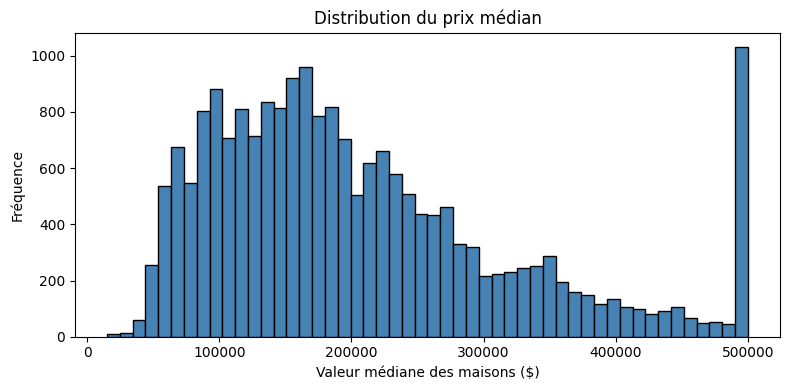

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['median_house_value'], bins=50, edgecolor='black', color='steelblue')
ax.set_xlabel('Valeur médiane des maisons ($)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution du prix médian')
plt.tight_layout()
plt.show()

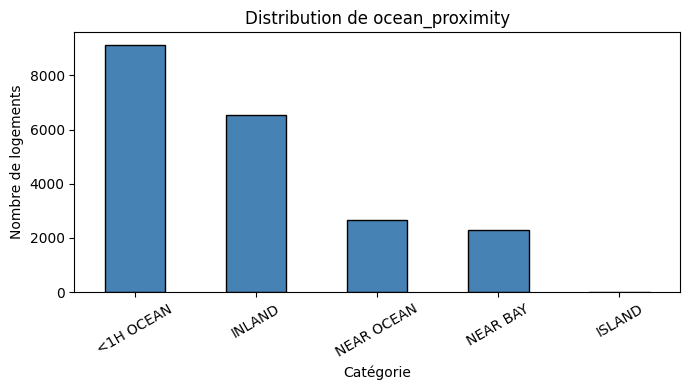

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
df['ocean_proximity'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Catégorie')
ax.set_ylabel('Nombre de logements')
ax.set_title('Distribution de ocean_proximity')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

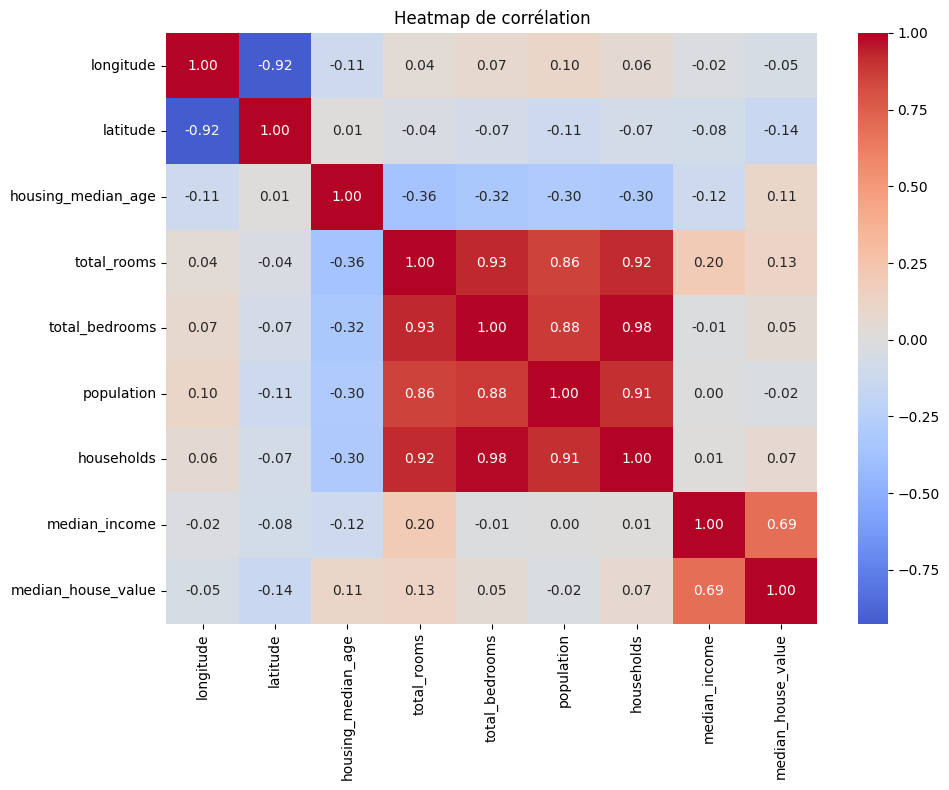

In [5]:
numeric_cols = df.select_dtypes(include='number').columns
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Heatmap de corrélation')
plt.tight_layout()
plt.show()

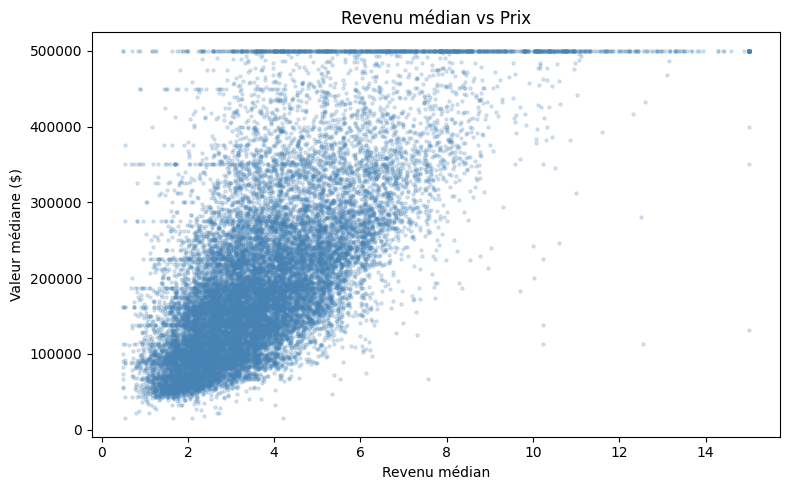

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['median_income'], df['median_house_value'], alpha=0.2, s=5, color='steelblue')
ax.set_xlabel('Revenu médian')
ax.set_ylabel('Valeur médiane ($)')
ax.set_title('Revenu médian vs Prix')
plt.tight_layout()
plt.show()